In [82]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
from scipy.optimize import minimize

import importlib
import SyntheticPhaseLinearMeasurement as SPLM
importlib.reload(SPLM)

%config InlineBackend.figure_format = 'retina'
cmap = plt.cm.viridis
rng = np.random.default_rng(seed=326890)   # PCG64 by default

# Model
## Phase drift and diffusion with measurement noise

The latent phase evolves according to the discrete-time stochastic process
\begin{equation}
    \theta_{k+1} = \theta_k + \omega \Delta t + \varepsilon_k, \quad \varepsilon_k \sim \mathcal{N}(0, Q), \quad Q = 2 D_\theta \Delta t
\end{equation}
The measurement model is linear
\begin{equation}
    y_k = \theta_k + \eta_k, \quad \eta_k \sim \mathcal{N}(0,R)
\end{equation}


### Simulated data

We can simulate data from this model as follows.

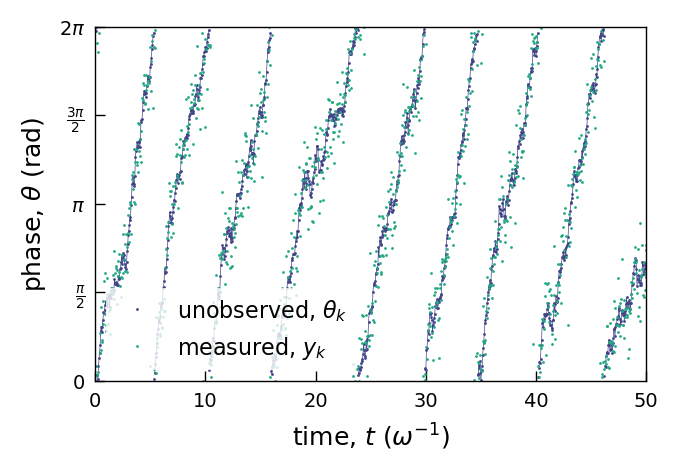

In [2]:
N = 1000 # number of data points
dt = 0.05 # time step, seconds

omega = 1.   # drift velocity
Dtheta = 0.1 # diffusion coefficient 
R = 0.4**2   # noise variance, radians^2
param = (omega,Dtheta,R)

## Simulate unwrapped phase data
tk, thetak, yk = SPLM.simulate_data(param, N, dt, rng)

# detect wrap points
thetak_wrap = np.mod(thetak, 2*np.pi)
dthetak = np.diff(thetak_wrap)
wrap = np.abs(dthetak) > np.pi
thetak_plot = thetak_wrap.copy()
thetak_plot[1:][wrap] = np.nan   # break the line

# Desired axes dimensions in centimeters
axes_width_cm = 7
axes_height_cm = 4.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
ax.plot(tk, thetak_plot, '-', lw=0.25, color=cmap(0.2))
ax.plot(tk, np.mod(thetak,2*np.pi), '.', ms=2, mew=0, label=r'unobserved, $\theta_k$', color=cmap(0.2))
ax.plot(tk, np.mod(yk,2*np.pi), '.', ms=2, mew=0, label='measured, $y_k$', color=cmap(0.6))

# Set axis labels with font size 9 pt
ax.set_xlabel(r'time, $t$ ($\omega^{-1}$)', fontsize=9)
ax.set_ylabel(r'phase, $\theta$ (rad)', fontsize=9)

# Create legend (frame turned off)
ax.legend(frameon=True, edgecolor='none', fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

ax.set_yticks([0,
               np.pi/2,
               np.pi,
               3*np.pi/2,
               2*np.pi])

ax.set_yticklabels([r'$0$',
                    r'$\frac{\pi}{2}$',
                    r'$\pi$',
                    r'$\frac{3\pi}{2}$',
                    r'$2\pi$'])

# Set the x-axis limits from 0 to 2000
ax.set_xlim(0, N*dt)
ax.set_ylim(0, 2*np.pi)

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SyntheticPhaseTrace.pdf')

In [3]:
list_of_tuples = list(zip(tk,yk,thetak))
df = pd.DataFrame(list_of_tuples,
                  columns=['t', 'y', 'theta'])
df

,t,y,theta
0,0.05,0.105093,-0.013761
1,0.10,0.264619,-0.085567
2,0.15,0.106573,0.005370
3,0.20,-0.282157,0.100610
4,0.25,0.159586,0.035731
...,...,...,...
995,49.80,52.375698,52.167878
996,49.85,52.181612,52.245197
997,49.90,51.881177,52.357124
998,49.95,52.593415,52.287346


In [4]:
df.to_csv('simulated_data_SP.csv',index=False)

### Mean squared displacement

The analysis of a diffusing particle is often characterized by the [mean squared displacement](https://en.wikipedia.org/wiki/Mean_squared_displacement) (MSD) of the particle position as a function of the lag time $\tau_n = n\Delta t$.  The MSD is defined as follows

$$ \text{msd} = \langle \Delta \theta^2_n\rangle = \frac{1}{N-n} \sum_{k=1}^{N-n} \left[\theta(t_{k+n}) - \theta(t_k)\right]^2  $$


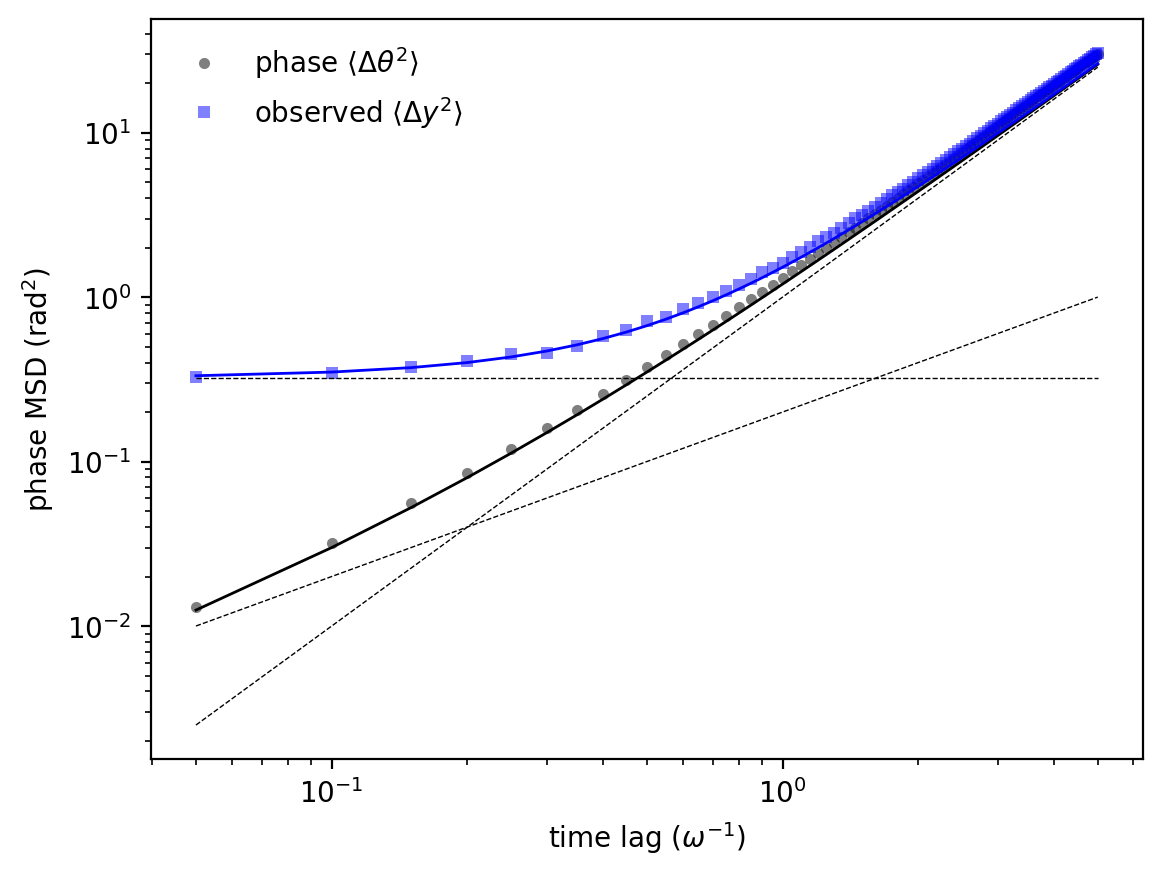

In [5]:
lags = 1+np.arange(100)

# non-overlapping intervals
theta_msds = np.zeros(lags.shape)
y_msds = np.zeros(lags.shape)

# overlapping intervals
theta_msds_ol = np.zeros(lags.shape)  
y_msds_ol = np.zeros(lags.shape) 

for i,lag in enumerate(lags):
    # non-overlapping
    theta_msds[i] = np.mean((thetak[lag::lag] - thetak[:-lag:lag])**2)  
    y_msds[i] = np.mean((yk[lag::lag] - yk[:-lag:lag])**2)

    # overlapping
    theta_msds_ol[i] = np.mean((thetak[lag:] - thetak[:-lag])**2)       
    y_msds_ol[i] = np.mean((yk[lag:] - yk[:-lag])**2)

# plt.loglog(dt*lags, theta_msds, 'ko', mew=0, ms=4, alpha=0.5, label=r'phase $\langle \Delta \theta^2 \rangle$')
plt.loglog(dt*lags, theta_msds_ol, 'ko', mew=0, ms=4, alpha=0.5, label=r'phase $\langle \Delta \theta^2 \rangle$')
plt.plot(dt*lags, 2*Dtheta*dt*lags + (omega*dt*lags)**2, 'k-', lw=1)

# plt.plot(dt*lags, y_msds, 'bs',  mew=0,ms=4, alpha=0.5,  label=r'observed $\langle \Delta y^2 \rangle$')
plt.plot(dt*lags, y_msds_ol, 'bs',  mew=0,ms=4, alpha=0.5,  label=r'observed $\langle \Delta y^2 \rangle$')
plt.plot(dt*lags, 2*R + 2*Dtheta*dt*lags + (omega*dt*lags)**2, 'b-', lw=1)

# theoretical result
plt.plot(dt*lags, 2*Dtheta*dt*lags, 'k--', lw=0.5)
plt.plot(dt*lags, (omega*dt*lags)**2, 'k--', lw=0.5)
plt.plot(dt*lags, 2*R*lags**0, 'k--', lw=0.5)

plt.ylabel(r'phase MSD (rad$^2$)')
plt.xlabel(r'time lag ($\omega^{-1}$)')
plt.legend(frameon=False);

#  Estimating latent phase, $p(\theta_{1:N} \mid y_{1:N}, \lambda)$

Given the parameters $\lambda=\{\theta_0, \omega,  D_\theta, R\}$ and the observed data $y_{1:N}=\{y_1,\dots,y_N\}$, we seek to infer the phase $\theta_{1:N}=\{\theta_1,\dots,\theta_N\}$ using a [Kalman filter](https://en.wikipedia.org/wiki/Kalman_filter)<sup id="fn1">[1](#f1)</sup> with Rauch-Tung-Striebel smoothing.<sup id="fn2">[2](#f2)</sup> This algorithm provides an efficient approach that scales linearly with the number of time steps $N$.

<p id="f1"><b>[1]</b> Kalman, R. E. (1960). "A New Approach to Linear Filtering and Prediction Problems". Journal of Basic Engineering. 82: 35–45. doi:10.1115/1.3662552.</p>
<p id="f2"><b>[2]</b> Rauch, H.E.; Tung, F.; Striebel, C. T. (August 1965). "Maximum likelihood estimates of linear dynamic systems". AIAA Journal. 3 (8): 1445–1450. doi:10.2514/3.3166.</p>


### Priors $p(\lambda)$

\begin{equation}
\begin{aligned}
    \theta_0 &\sim \mathcal{N}( \mu_\theta, \sigma^2_\theta )
    \\
    \omega &\sim \mathcal{N}( \mu_\omega, \sigma^2_\omega )
\end{aligned}
\qquad
\begin{aligned}
    D_\theta &\sim \mathrm{Inv\text{-}Gamma}(\alpha_D, \beta_D)
    \\
    R &\sim \mathrm{Inv\text{-}Gamma}(\alpha_R, \beta_R)
\end{aligned}
\end{equation}

In [6]:
# Priors 
mu_theta = 0
sigma_theta = 2*np.pi
mu_omega = omega
sigma_omega = omega
alpha_D = 1
beta_D = 1
alpha_R = 1
beta_R = 1

priors = (mu_theta, sigma_theta, mu_omega, sigma_omega, alpha_D, beta_D, alpha_R, beta_R)

## Forward Kalman Filter

In [7]:
# Kalman filter
param = (omega, Dtheta, R)
data = (tk, yk)
thetakk, Pkk, thetakk_1, Pkk_1 = SPLM.kalman_filter(param, data, priors)

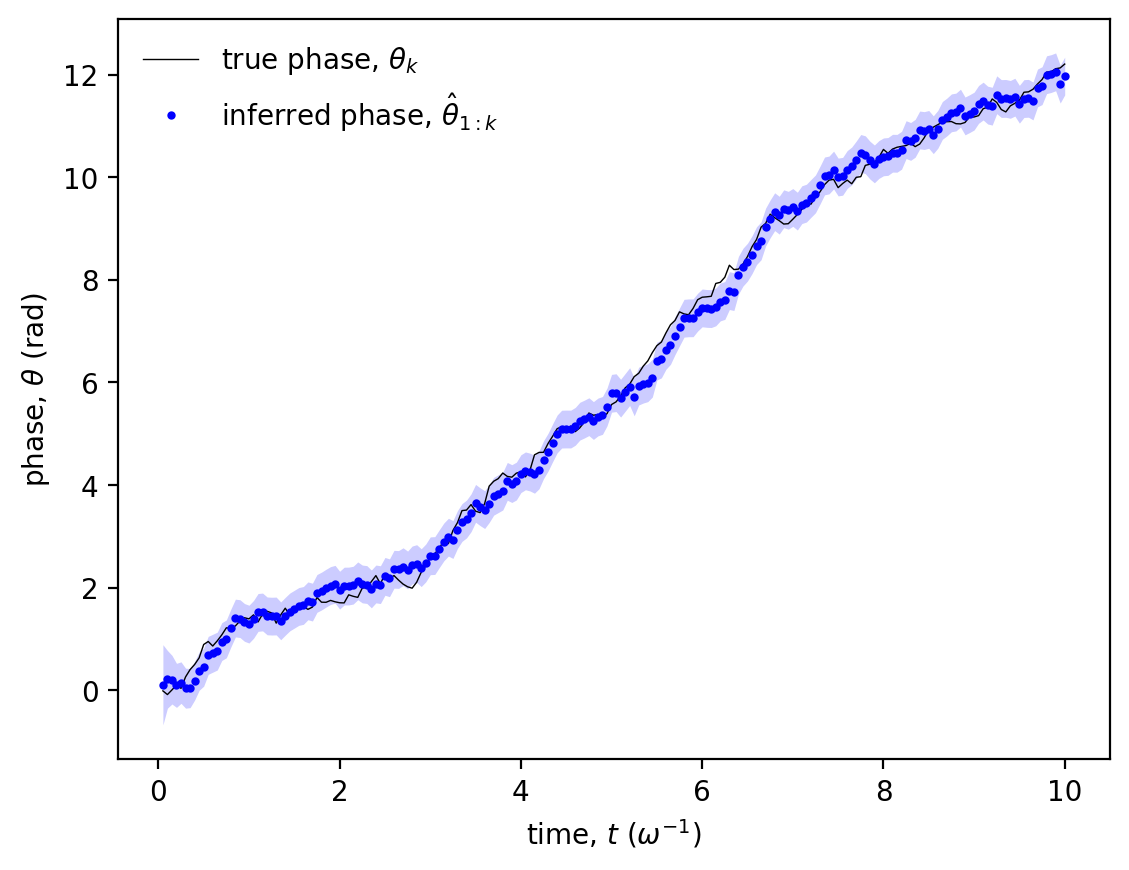

In [8]:
kmax = 200
plt.plot(tk[:kmax], thetak[:kmax], '-', c='k', lw=0.5, label=r'true phase, $\theta_k$')
plt.plot(tk[:kmax], thetakk[:kmax], '.', c='b', ms=4, label=r'inferred phase, $\hat{\theta}_{1:k}$')
plt.fill_between(tk[:kmax], thetakk[:kmax] + 1.96*np.sqrt(Pkk[:kmax]), thetakk[:kmax] - 1.96*np.sqrt(Pkk[:kmax]), 
                 color='b', alpha=0.2, lw=0);

plt.xlabel(r'time, $t$ ($\omega^{-1}$)')
plt.ylabel(r'phase, $\theta$ (rad)')
plt.legend(frameon=False);

## Backward Rauch-Tung-Striebel (RTS) Smoother

In [9]:
kalman_phases = (thetakk, Pkk, thetakk_1, Pkk_1)
thetakN, PkN, Sigmakk_1 = SPLM.rts_smoother(param, data, kalman_phases)

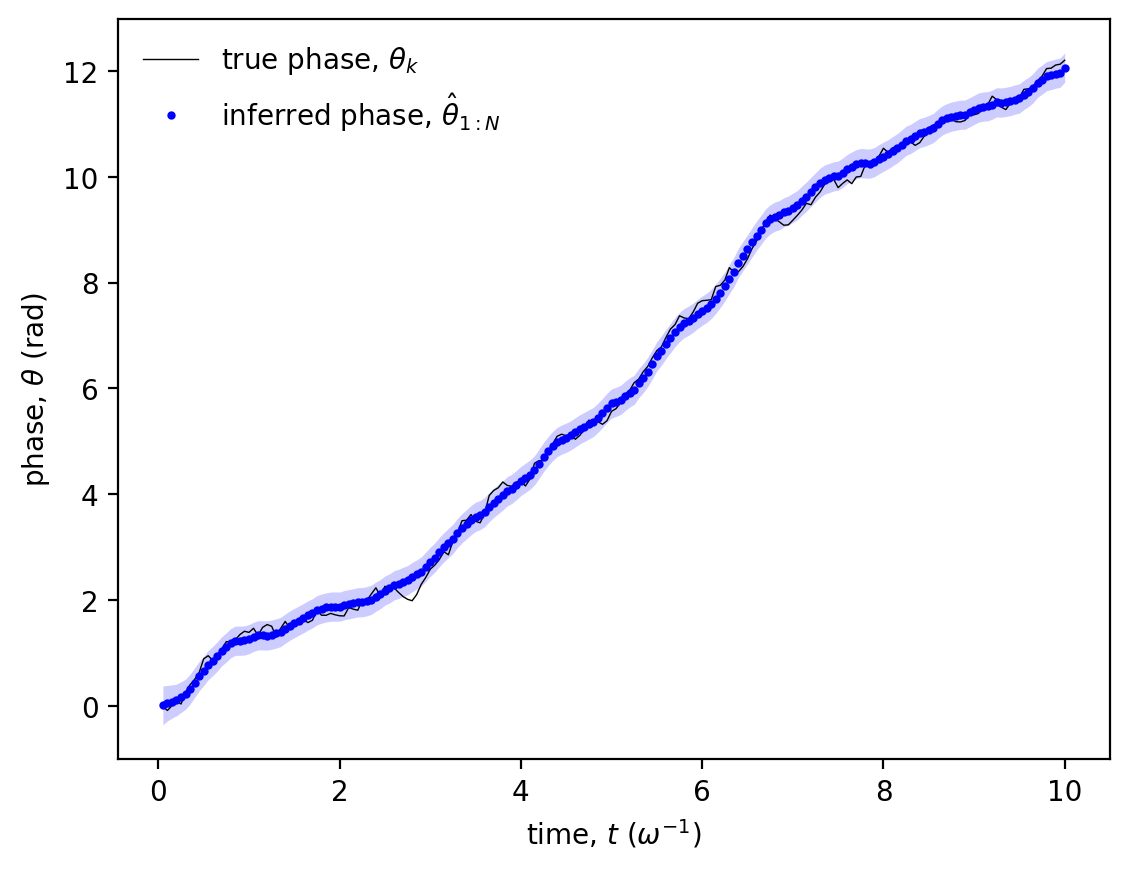

In [10]:
kmax = 200
plt.plot(tk[:kmax], thetak[:kmax], '-', c='k', lw=0.5, label=r'true phase, $\theta_k$')
plt.plot(tk[:kmax], thetakN[:kmax], '.', c='b', ms=4, label=r'inferred phase, $\hat{\theta}_{1:N}$')
plt.fill_between(tk[:kmax], thetakN[:kmax] + 1.96*np.sqrt(PkN[:kmax]), thetakN[:kmax] - 1.96*np.sqrt(PkN[:kmax]), 
                 color='b', alpha=0.2, lw=0);

plt.xlabel(r'time, $t$ ($\omega^{-1}$)')
plt.ylabel(r'phase, $\theta$ (rad)')
plt.legend(frameon=False);

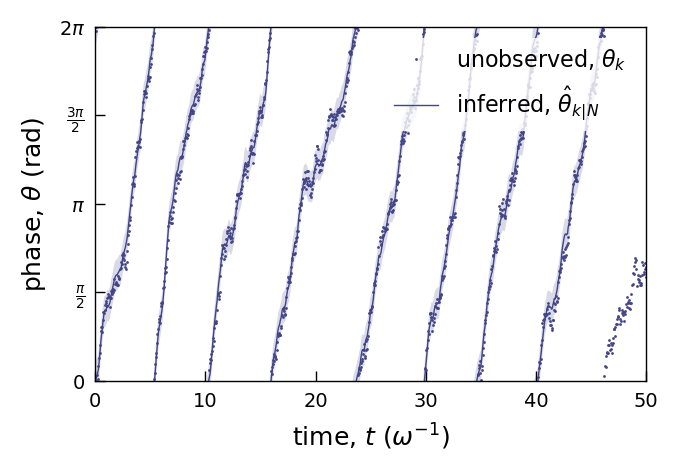

In [11]:
# Desired axes dimensions in centimeters
axes_width_cm = 7
axes_height_cm = 4.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
ax.plot(tk, np.mod(thetak, 2*np.pi), '.', ms=2, mew=0, label=r'unobserved, $\theta_k$', color=cmap(0.2))
ax.plot(tk, thetakN + 2*np.pi, '-', lw=0.5, label=r'inferred, $\hat{\theta}_{k|N}$', color=cmap(0.2))

thetakN_upper = thetakN + 1.96*np.sqrt(PkN)
thetakN_lower = thetakN - 1.96*np.sqrt(PkN)
ax.fill_between(tk, thetakN_upper + 2*np.pi, thetakN_lower + 2*np.pi, color=cmap(0.2), alpha=0.2, lw=0);

for i in range(0,8):
    ax.plot(tk, thetakN - i*2*np.pi, '-', lw=0.5, color=cmap(0.2))
    ax.fill_between(tk, thetakN_upper - i*2*np.pi, thetakN_lower - i*2*np.pi, color=cmap(0.2), alpha=0.2, lw=0);


# Set axis labels with font size 9 pt
ax.set_xlabel(r'time, $t$ ($\omega^{-1}$)', fontsize=9)
ax.set_ylabel(r'phase, $\theta$ (rad)', fontsize=9)

# Create legend (frame turned off)
ax.legend(frameon=True, fontsize=8, edgecolor='none', loc=1)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

ax.set_yticks([0,
               np.pi/2,
               np.pi,
               3*np.pi/2,
               2*np.pi])

ax.set_yticklabels([r'$0$',
                    r'$\frac{\pi}{2}$',
                    r'$\pi$',
                    r'$\frac{3\pi}{2}$',
                    r'$2\pi$'])

ax.set_xlim(0, N*dt)
ax.set_ylim(0, 2*np.pi)

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SyntheticPhaseTrace_Inferred.pdf')

## Mean Squared Displacement (revisited)

In [12]:
# Solve Ax = rhs
Sigma = SPLM.theta_covariance(param, data, priors)

The diagonal entries are the same as those obtained from the Kalman filter above.

In [13]:
error = np.array([np.linalg.norm(Sigma[k,k] - PkN[k]) for k in range(N)])
print(error.mean())

2.033187208524967e-11


We can compute the relevant elements in a more efficient way as follows.

In [14]:
error = np.array([(Sigma[k,k-1]-Sigmakk_1[k]) for k in range(1,N)])
print(error.mean())

-1.5860578432167925e-11


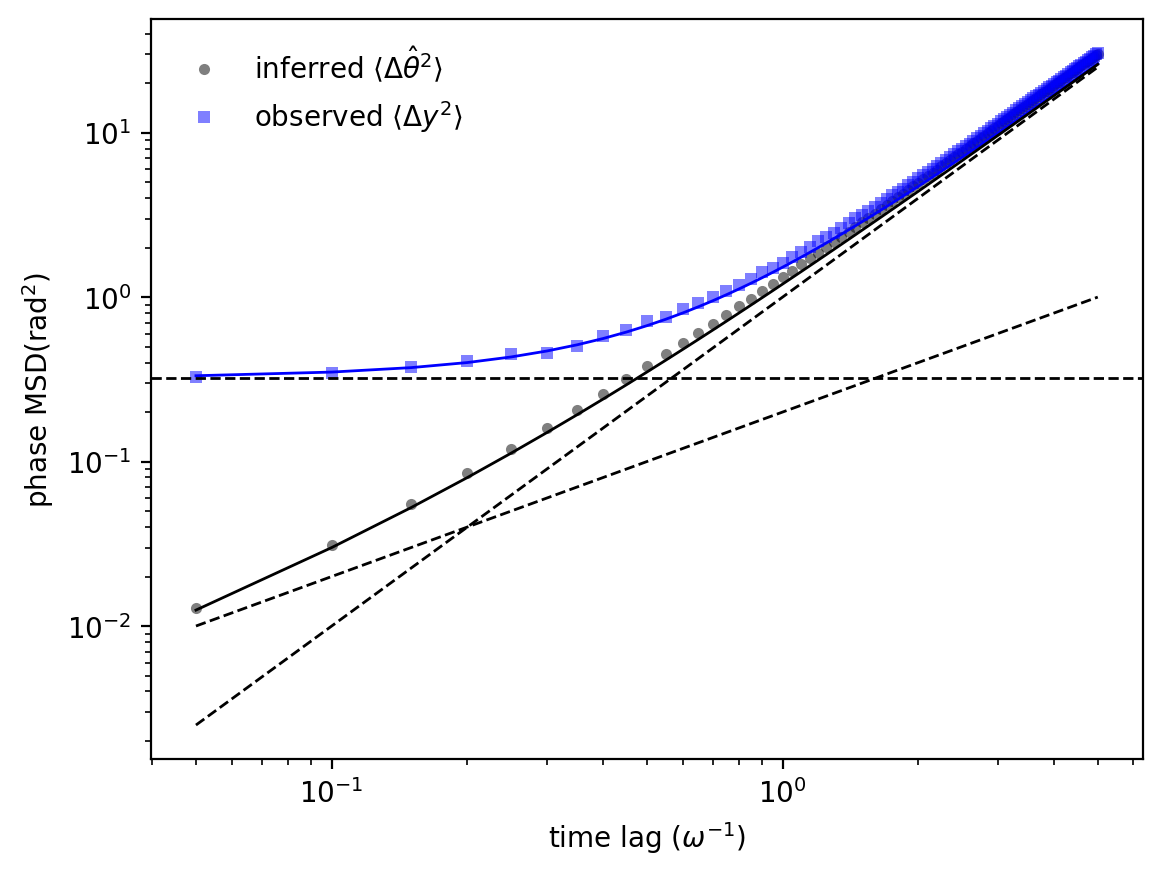

In [15]:
lags = 1+np.arange(100)
thetahat_msds = np.zeros(lags.shape)     # non-overlapping
thetahat_msds_ol = np.zeros(lags.shape)  # overlapping

for i,lag in enumerate(lags):
    thetahat_msds[i] = np.mean((thetakN[lag::lag] - thetakN[:-lag:lag])**2 + np.diag(Sigma)[lag::lag] + np.diag(Sigma)[:-lag:lag]
                           - 2*np.diag(Sigma,k=lag)[::lag])  # non-overlapping
    thetahat_msds_ol[i] = np.mean((thetakN[lag:] - thetakN[:-lag])**2 + np.diag(Sigma)[lag:] + np.diag(Sigma)[:-lag]
                           - 2*np.diag(Sigma,k=lag))         # overlapping
    
# plt.loglog(dt*lags, thetahat_msds, 'ko', mew=0, ms=4, alpha=0.5, label=r'inferred $\langle \Delta x^2 \rangle$')
plt.loglog(dt*lags, thetahat_msds_ol, 'ko', mew=0, ms=4, alpha=0.5, label=r'inferred $\langle \Delta \hat{\theta}^2 \rangle$')

# plt.plot(dt*lags, y_msds, 'bs',  mew=0,ms=4, alpha=0.5,  label=r'observed $\langle \Delta y^2 \rangle$')
plt.plot(dt*lags, y_msds_ol, 'bs',  mew=0,ms=4, alpha=0.5,  label=r'observed $\langle \Delta y^2 \rangle$')

plt.plot(dt * lags, 2*R + 2 * Dtheta * dt * lags + (omega * dt * lags)**2, 'b-', lw=1)
plt.plot(dt * lags, 2 * Dtheta * dt * lags + (omega * dt * lags)**2, 'k-', lw=1)
plt.plot(dt * lags, (omega * dt * lags)**2, 'k--', lw=1)
plt.plot(dt * lags, 2 * Dtheta * dt * lags, 'k--', lw=1)

plt.axhline(y=2*R, color='k', ls='--', lw=1)
plt.ylabel(r'phase MSD(rad$^2$)')
plt.xlabel(r'time lag ($\omega^{-1}$)')
plt.legend(frameon=False);

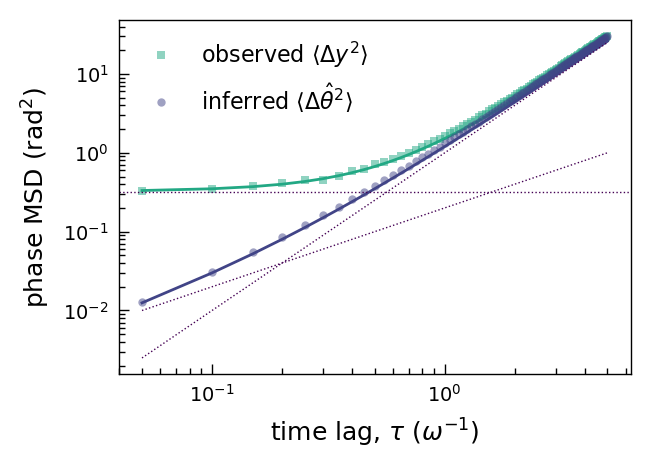

In [16]:
# Desired axes dimensions in centimeters
axes_width_cm = 6.5
axes_height_cm = 4.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
# ax.plot(dt*lags, y_msds, 's',  mew=0,ms=3, alpha=0.5,  color=cmap(0.6),
#         label=r'observed $\langle \Delta y^2 \rangle$')
ax.plot(dt*lags, y_msds_ol,  's',  mew=0,ms=3, alpha=0.5,  color=cmap(0.6),
        label=r'observed $\langle \Delta y^2 \rangle$')
ax.plot(dt*lags, 2*R + 2*Dtheta*dt*lags +  (omega*dt*lags)**2, '-', lw=1, color=cmap(0.6))

# ax.loglog(dt*lags, thetahat_msds, 'o', mew=0, ms=3, color=cmap(0.2), alpha=0.5, 
# label=r'inferred $\langle \Delta \hat{\theta}^2 \rangle$')
ax.loglog(dt*lags, thetahat_msds_ol,  'o', mew=0, ms=3, color=cmap(0.2), alpha=0.5, 
          label=r'inferred $\langle \Delta \hat{\theta}^2 \rangle$')
ax.plot(dt*lags, 2*Dtheta*dt*lags +  (omega*dt*lags)**2, '-', lw=1, color=cmap(0.2))

# Theory
ax.plot(dt*lags, (omega*dt*lags)**2, ':', lw=0.5, color=cmap(0))
ax.plot(dt*lags, 2*Dtheta*dt*lags, ':', lw=0.5, color=cmap(0))
plt.axhline(y = 2*R,  ls=':', lw=0.5, color=cmap(0))

# Set axis labels with font size 9 pt
ax.set_xlabel(r'time lag, $\tau$ ($\omega^{-1}$)', fontsize=9)
ax.set_ylabel(r'phase MSD (rad$^2$)', fontsize=9)

# Create legend (frame turned off)
ax.legend(frameon=False, fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SyntheticPhaseMSD.pdf')

# Estimating parameters, $p(\lambda \mid y_{1:N})$

## Expectation Maximization (EM) Algorithm

Complete-data log likelihood $\ell_c(\lambda; \theta, y) = \ln p(\theta, y\mid \lambda)$ is given by 

$$ \ell_c(\lambda; \theta, y)  = \text{const.} - \tfrac{1}{2} N \ln D_\theta - \frac{1}{4 D_\theta \Delta t} \sum_{k=1}^{N-1} (\theta_{k+1} - \theta_k - \omega \Delta t)^2 - \tfrac{1}{2} N \ln R - \frac{1}{2 R} \sum_{k=1}^N (y_k - \theta_{k})^2 $$

### Expectation Step

$$ Q(\lambda , \lambda_j) = \mathbb{E}_{\theta\sim p(\cdot\mid y,\lambda_j)} \big[ \ln p(\theta, y \mid \lambda)\big] + \ln p(\lambda) $$

Substituting the prior and the complete-data likelihood, we can write this function as 

\begin{align}
\begin{split}
    Q(\lambda , \lambda_j)  &= \text{const.} - \frac{(\omega - \mu_\omega)^2}{2\sigma_\omega^2}    - (\alpha_D + 1)\ln D_\theta - \frac{\beta_D}{D_\theta}  -(\alpha_R + 1)\ln R - \frac{\beta_R}{R}
    \\
    & -\tfrac{1}{2} N \ln D_\theta- \frac{1}{4 D_\theta \Delta t}\left[\hat{S}_0 - 2\hat{S}_1 \omega \Delta t + (N-1) (\omega \Delta t)^2 \right]
    \\
    &- \tfrac{1}{2} N \ln R - \frac{\hat{S}_y}{2 R} 
\end{split}
\end{align}

where the relevant statistics are 

\begin{align}
    \hat{S}_0 &= \sum_{k=1}^{N-1} \left[ (\hat{\theta}_{k+1} - \hat{\theta}_k)^2 + \Sigma_{k+1,k+1} + \Sigma_{k,k} - 2\Sigma_{k+1,k} \right]
    \\
    \hat{S}_1 &= \sum_{k=1}^{N-1} (\hat{\theta}_{k+1} - \hat{\theta}_{k}) = \hat{\theta}_N - \hat{\theta}_1 
    \\
    \hat{S}_y &= \sum_{k=1}^N \left[(y_k - \hat{\theta}_{k})^2 + \Sigma_{k,k}\right] 
\end{align}

### Maximization Step
In the second maximization step of the EM algorithm, we seek to maximize the expected log posterior $Q(\lambda ,\lambda_j)$ with respect to the parameters $\lambda=\{\theta_0, \omega,  D_\theta, R\}$. 

**Noise variance $R$**

In [17]:
Sy = np.sum((thetakN-yk)**2 + PkN)
R_new = (2*beta_R + Sy) / (2*(alpha_R + 1) + N)

print(f'noise variance, R: old = {R:.5}, new = {R_new:.5}')

noise variance, R: old = 0.16, new = 0.15975


**Frequency $\omega$, Diffusivity $D_\theta$.**

If we consider ingorance priors, then the results can be computed analytically.

In [18]:
# frequency
S1 = thetakN[-1] - thetakN[0]
omega_new = S1 / ((N-1)*dt)

# phase diffusivity
S0 = np.sum((thetakN[1:] - thetakN[:-1])**2 + PkN[1:] + PkN[:-1] - 2*Sigmakk_1[1:])
Dtheta_new = S0 / (2*(N+2)*dt)

print(f'frequency, omega:\told = {omega:.5f}, new = {omega_new:.5f}')
print(f'diffusivity, Dtheta:\told = {Dtheta:.5f}, new = {Dtheta_new:.5f}')

frequency, omega:	old = 1.00000, new = 1.05035
diffusivity, Dtheta:	old = 0.10000, new = 0.12755


If we use specified priors, then we can compute the optimum numerically.

In [19]:
# Statistics 
statistics = (N, dt, S0, S1, Sy)

# Optimize    
tol = 1e-5
guess = [omega_new, np.log(Dtheta_new)]

res = minimize(SPLM.objective, guess, args=(priors, statistics), jac=SPLM.jac, tol=tol, method='L-BFGS-B')
print(res)

print(f'frequency, omega:\told = {omega:.5f}, new = {res.x[0]:.5f}')
print(f'diffusivity, Dtheta:\told = {Dtheta:.5f}, new = {np.exp(res.x[1]):.5f}')

  message: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
  success: True
   status: 0
      fun: -644.734957062194
        x: [ 1.050e+00 -2.284e+00]
      nit: 3
      jac: [ 5.766e-03  1.120e-02]
     nfev: 5
     njev: 5
 hess_inv: <2x2 LbfgsInvHessProduct with dtype=float64>
frequency, omega:	old = 1.00000, new = 1.05017
diffusivity, Dtheta:	old = 0.10000, new = 0.10184


### Iterate to find MAP estimates

In [20]:
guess = [omega, Dtheta, R]
lambda_iter = SPLM.infer_MAP_parameters(guess, data, priors, max_iter=200, tol=1e-6, verbose=True, print_every=10)

iter	omega		Dtheta		R
1	1.05017e+00	1.01844e-01	1.59747e-01
10	1.05049e+00	1.13818e-01	1.58288e-01
20	1.05047e+00	1.20511e-01	1.57528e-01
30	1.05047e+00	1.23623e-01	1.57186e-01
40	1.05047e+00	1.25043e-01	1.57032e-01
50	1.05046e+00	1.25686e-01	1.56963e-01
60	1.05046e+00	1.25975e-01	1.56931e-01
70	1.05046e+00	1.26106e-01	1.56917e-01
80	1.05046e+00	1.26165e-01	1.56911e-01
90	1.05046e+00	1.26191e-01	1.56908e-01
100	1.05046e+00	1.26203e-01	1.56907e-01
110	1.05046e+00	1.26208e-01	1.56906e-01
120	1.05046e+00	1.26211e-01	1.56906e-01

Converged at iteration 124 (max relative change = 9.38e-07)


## Convergence


In [21]:
# MAP parameters
lambda_map = lambda_iter[-1,:]
omega_map = lambda_map[0]
Dtheta_map = lambda_map[1]
R_map = lambda_map[2]

#### Filter and Smooth
kalman_phases = SPLM.kalman_filter(lambda_map, data, priors)
thetakN, PkN, Sigmakk_1 = SPLM.rts_smoother(lambda_map, data, kalman_phases)

#### Statistics 
N = yk.shape[0]
dt = tk[1]-tk[0]
S0 = np.sum((thetakN[1:] - thetakN[:-1])**2 + PkN[1:] + PkN[:-1] - 2*Sigmakk_1[1:])
S1 = thetakN[-1] - thetakN[0] 
Sy = np.sum((yk - thetakN)**2 + PkN)
statistics = (N, dt, S0, S1, Sy)

RMS error = 0.018856
Convergence rate = 0.08015


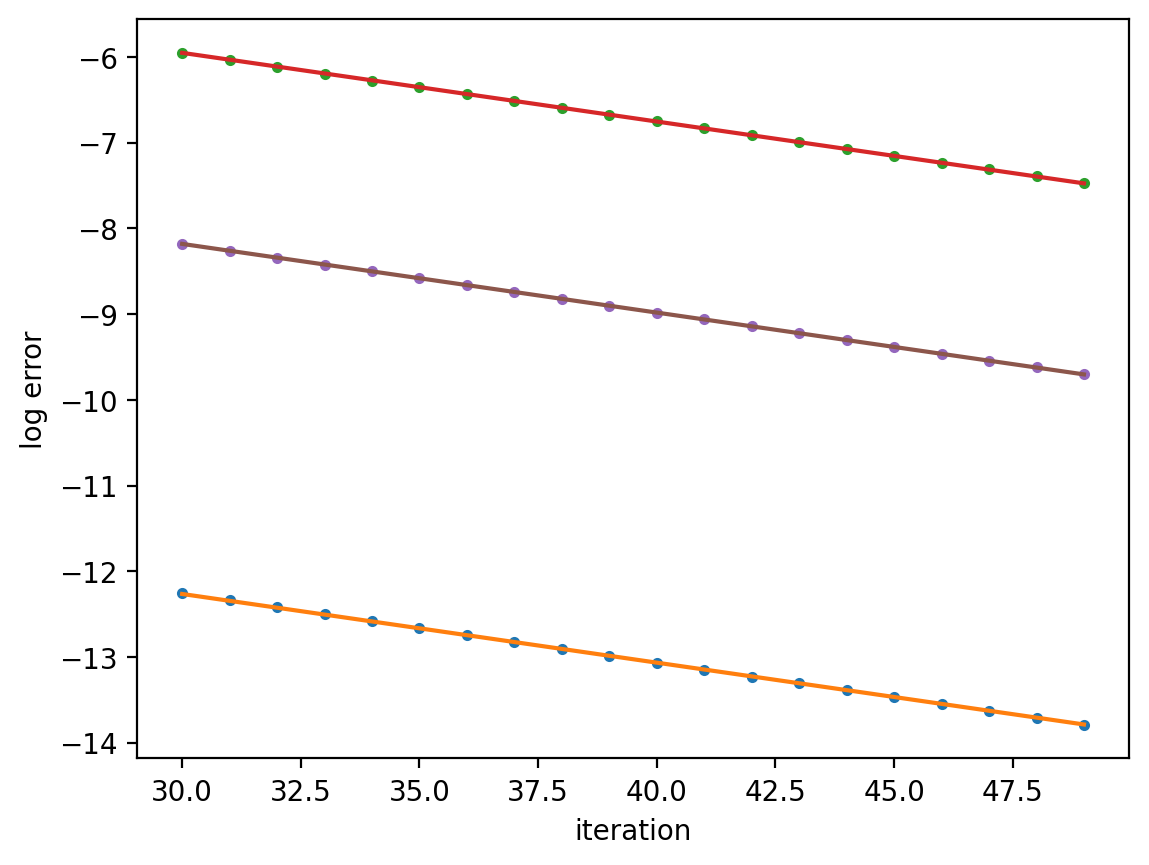

In [101]:
# Calculate convergence rate 
imin = 30
imax = 50
iN = imax-imin
y = np.concatenate(( np.log(np.abs(lambda_iter[imin:imax,0] - lambda_iter[-1,0])),
                     np.log(np.abs(lambda_iter[imin:imax,1] - lambda_iter[-1,1])),
                     np.log(np.abs(lambda_iter[imin:imax,2] - lambda_iter[-1,2])) ))
x = np.arange(imin,imax)

DM = np.concatenate(( np.column_stack(( x**0,  0*x,  0*x, -x)),
                      np.column_stack((  0*x, x**0,  0*x, -x)),
                      np.column_stack((  0*x,  0*x, x**0, -x)) ))
coeff = np.linalg.lstsq(DM, y, rcond=None)[0]
fit = DM@coeff

for i in range(3):
    plt.plot(x,y[i*iN:(i+1)*iN],'.')
    plt.plot(x,fit[i*iN:(i+1)*iN])
plt.xlabel('iteration')
plt.ylabel('log error')

error = np.sqrt(np.sum((fit - y)**2))
print('RMS error = %f'%error)

rate = coeff[-1]
print(f'Convergence rate = {rate:.5f}')

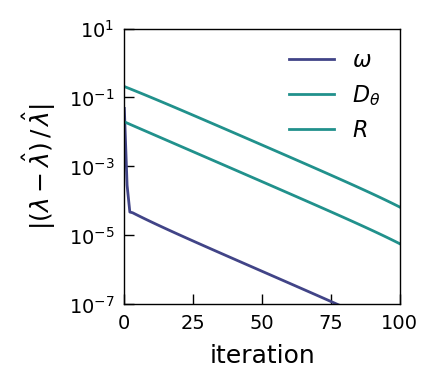

In [102]:
# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.8
right_margin = 0.2
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
ax.semilogy(np.abs((lambda_iter[:,0]-lambda_map[0])/lambda_map[0]), label=r'$\omega$', color=cmap(0.2), lw=1)
ax.semilogy(np.abs((lambda_iter[:,1]-lambda_map[1])/lambda_map[1]), label=r'$D_\theta$', color=cmap(0.5), lw=1)
ax.semilogy(np.abs((lambda_iter[:,2]-lambda_map[2])/lambda_map[2]), label=r'$R$', color=cmap(0.5), lw=1)
# ax.plot(x+jmin, 0.3*np.exp(fit[:jN])/np.abs(lambda_hat[0]), 'k--', lw=1)

# Set axis labels with font size 9 pt
ax.set_xlabel(r'iteration', fontsize=9)
ax.set_ylabel(r'$| (\lambda - \hat{\lambda}) \, / \, \hat{\lambda}|$', fontsize=9)
plt.ylim(1e-7,10)
plt.xlim(0,100)

# Create legend (frame turned off)
ax.legend(frameon=False, fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SyntheticPhaseConvergence.pdf')

## Sampling Phase Trajectories

In [103]:
N_samples = 10000
theta_samples = SPLM.sample_phases(lambda_map, data, priors, rng, N_samples)

# Compute statistics
S0_samples = np.sum((theta_samples[:,1:] - theta_samples[:,:-1])**2, axis=1)
S1_samples = theta_samples[:,-1] - theta_samples[:,0]
Sy_samples = np.sum((yk[None,:] - theta_samples)**2, axis=1)
samples = (S0_samples, S1_samples, Sy_samples)

### Statistics

$$ S_y =\sum _{k=1}^N \left( y_k-\theta_k \right)^2 $$

True mean = 155.534
MC mean   = 155.604 +/- 0.031
Z-score   = -2.248


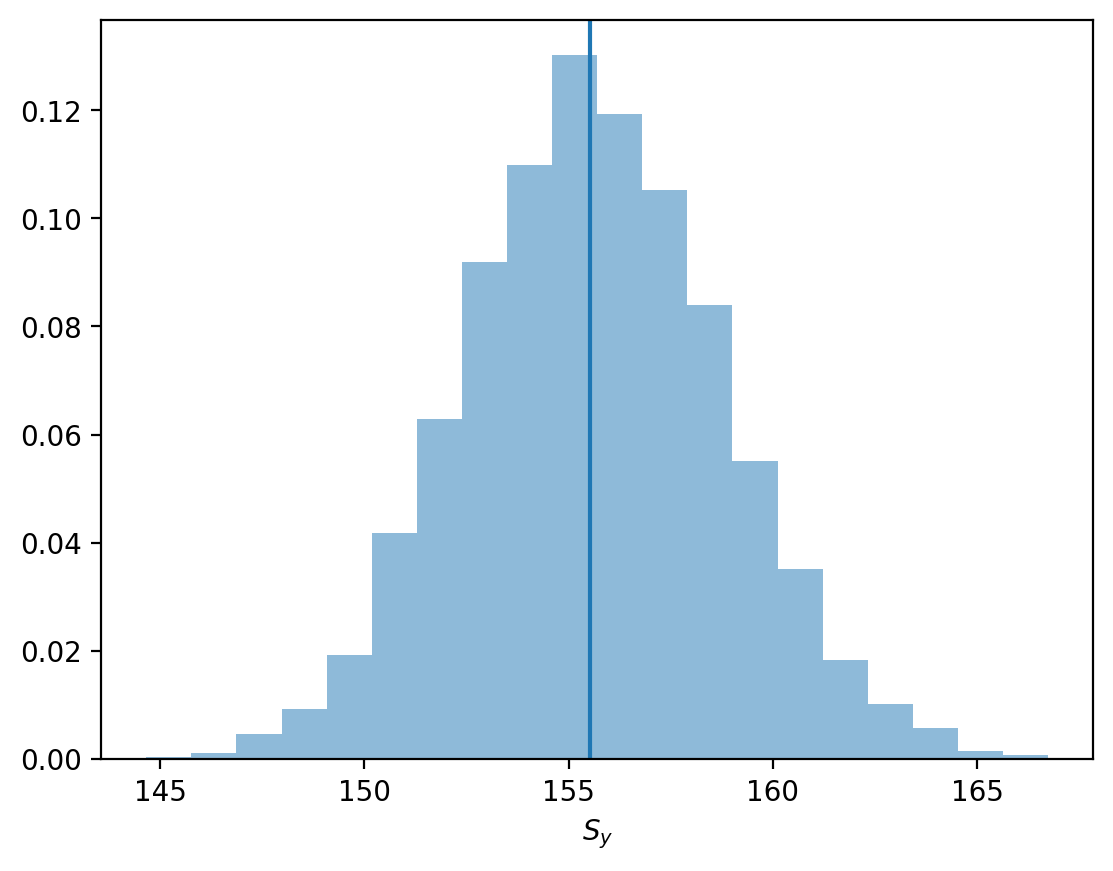

In [104]:
Sy_mean = np.sum((yk - thetakN)**2 + PkN)
Sy_samples_mean = np.mean(Sy_samples)
Sy_samples_std = np.std(Sy_samples, ddof=1)
Sy_samples_se = Sy_samples_std / np.sqrt(N_samples)

print(f'True mean = {Sy_mean:.6}')
print(f'MC mean   = {Sy_samples_mean:.3f} +/- {Sy_samples_se:.3f}')
print(f'Z-score   = {(Sy_mean - Sy_samples_mean)/ Sy_samples_se:.3f}')
    
plt.hist(Sy_samples, bins=20, alpha=0.5, density=True)
plt.axvline(x=Sy_mean)
plt.xlabel('$S_y$');

$$ S_0 = \sum _{k=2}^N \left(\theta_k-\theta_{k-1}\right)^2$$

True mean = 15.2284
MC mean   = 15.232 +/- 0.005
Z-score   = -0.710


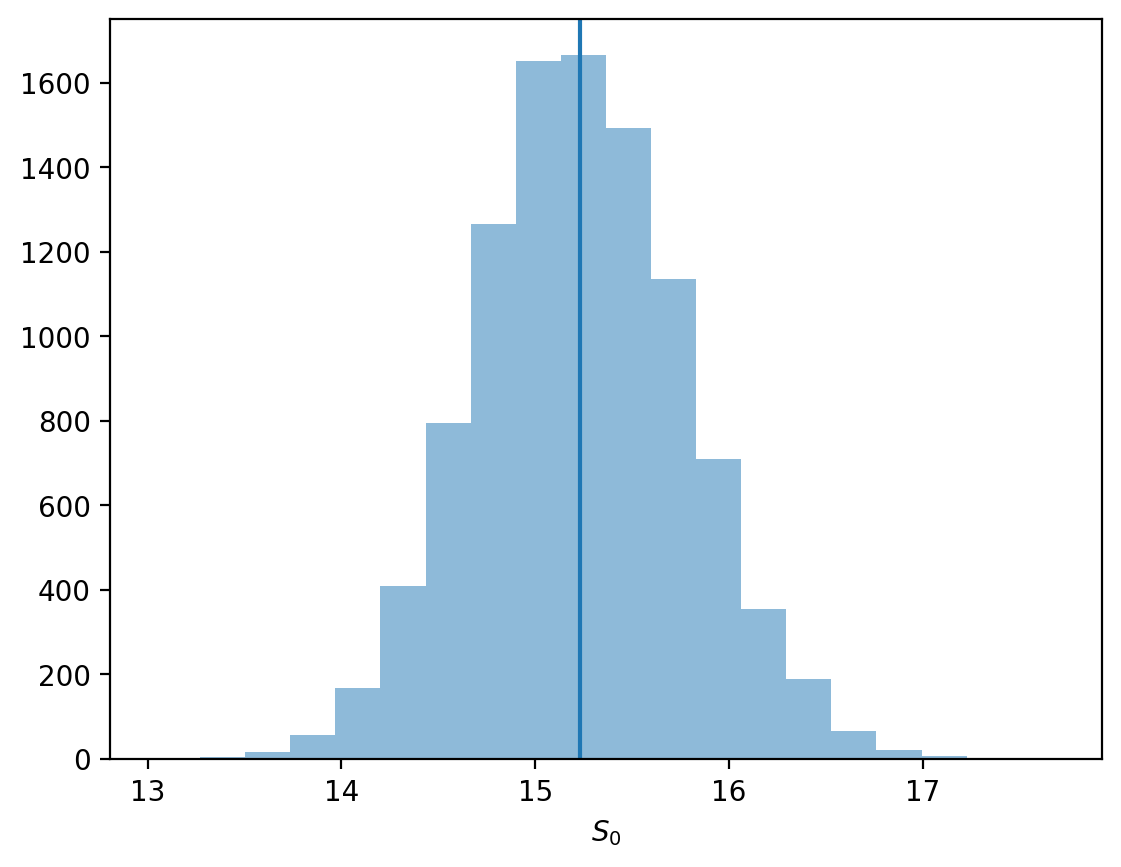

In [105]:
S0_mean = np.sum((thetakN[1:] - thetakN[:-1])**2 + PkN[1:] + PkN[:-1] - 2*Sigmakk_1[1:])

S0_samples = np.sum((theta_samples[:,1:] - theta_samples[:,:-1])**2, axis=1)
S0_samples_mean = np.mean(S0_samples)
S0_samples_std = np.std(S0_samples, ddof=1)
S0_samples_se = S0_samples_std / np.sqrt(N_samples)

print(f'True mean = {S0_mean:.6}')
print(f'MC mean   = {S0_samples_mean:.3f} +/- {S0_samples_se:.3f}')
print(f'Z-score   = {(S0_mean - S0_samples_mean)/ S0_samples_se:.3f}')
    
plt.hist(S0_samples, bins=20, alpha=0.5)
plt.axvline(x=S0_mean)
plt.xlabel('$S_0$');

$$ S_1 = \sum _{k=2}^N \left(\theta_k-\theta_{k-1}\right)$$

True mean = 52.4808
MC mean   = 52.479 +/- 0.003
Z-score   = 0.520


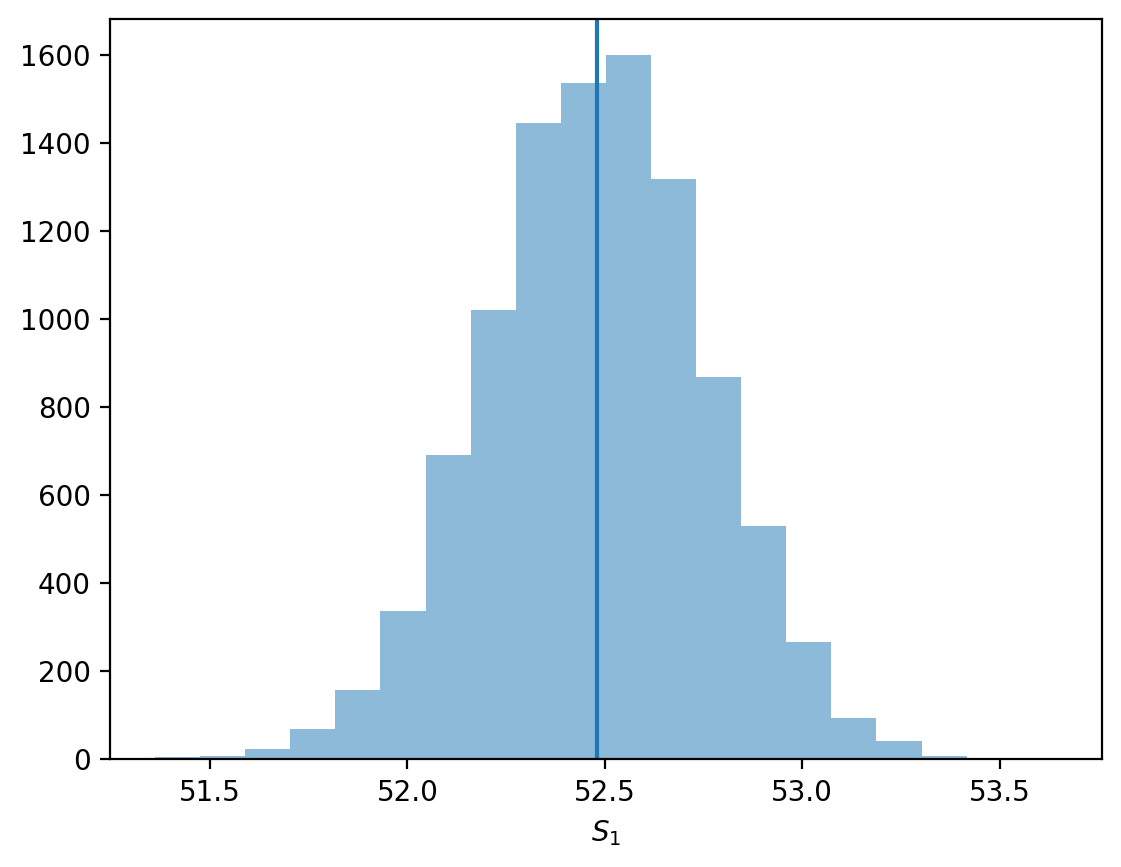

In [106]:
S1_mean = np.sum(thetakN[1:] - thetakN[:-1])

S1_samples_mean = np.mean(S1_samples)
S1_samples_std = np.std(S1_samples, ddof=1)
S1_samples_se = S1_samples_std / np.sqrt(N_samples)
 
print(f'True mean = {S1_mean:.6}')
print(f'MC mean   = {S1_samples_mean:.3f} +/- {S1_samples_se:.3f}')
print(f'Z-score   = {(S1_mean - S1_samples_mean)/ S1_samples_se:.3f}')
    
plt.hist(S1_samples, bins=20, alpha=0.5)
plt.axvline(x=S1_mean)
plt.xlabel('$S_1$');

## Uncertainty Estimate

We will parameterize as $\lambda = \{\omega, \ln D_\theta, \ln R \}$.

### Prior Information Matrix, $\mathcal{I}_{\text{prior}}=-\nabla_\lambda^2 \ln p(\lambda)\rvert_{\hat{\lambda}}$


In [107]:
I_prior = SPLM.prior_information(lambda_map, priors)

print(I_prior)

[[1.         0.         0.        ]
 [0.         7.92323335 0.        ]
 [0.         0.         6.37323886]]


### Complete-data Information, $\mathcal{I}_{\text{comp}} = -\mathbb{E}[\nabla_\lambda^2 \ell_c(\lambda;\theta,y)\mid y, \hat{\lambda}]$ 

In [108]:
I_comp = SPLM.complete_data_information(lambda_map, statistics)

print(I_comp)

[[1.97882753e+02 4.01444851e-02 0.00000000e+00]
 [4.01444851e-02 4.94070669e+02 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 4.95626724e+02]]


### Missing Information, $\mathcal{I}_{\text{miss}} = \mathrm{Cov}(\nabla_\lambda \ell_c(\lambda; \theta, y)\mid y, \hat{\lambda})$ 

Here, we use a Monte Carlo estimator.

In [109]:
I_miss_MC = SPLM.missing_information_MC(lambda_map, data, priors, rng, N_samples)

print(I_miss_MC)

[[ 1.22607962e+00  2.31551290e-01 -1.24729461e-01]
 [ 2.31551290e-01  4.60839592e+02 -2.98342854e+01]
 [-1.24729461e-01 -2.98342854e+01  9.89661944e+01]]


Check that the score is approximately zero for the optimum parameters.

In [110]:
score_prior = np.zeros((3,))
score_prior[0] = -(omega_map - mu_omega)/sigma_omega**2
score_prior[1] = -(alpha_D+1) + beta_D/Dtheta_map
score_prior[2] = -(alpha_R+1) + beta_R/R_map

sbar = score.mean(axis=0)
se = score.std(axis=0, ddof=1)/np.sqrt(score.shape[0])
print("mean:", sbar)
print("SE  :", se)
print("z   :", (sbar + score_prior)/se)

mean: [ 0.03305138 -5.68526204 -4.23606968]
SE  : [0.01095933 0.21289252 0.10010089]
z   : [-1.5887929   1.11780022  1.37030934]


Alternatively, we can compute the missing information analytically.

In [111]:
I_miss = SPLM.missing_information(
    y=yk,                 # shape (N,)
    m=thetakN,         # smoother mean at MAP, shape (N,)
    omega=omega_map,
    D=Dtheta_map,
    R=R_map,
    dt=dt,
    sigma_theta2=sigma_theta**2,
)

print(I_miss)

[[ 1.21213116e+00 -2.27601647e-02  2.27478501e-02]
 [-2.27601647e-02  4.60744457e+02 -3.11913083e+01]
 [ 2.27478501e-02 -3.11913083e+01  1.01637183e+02]]


In [112]:
SPLM.assess_diff_vs_mc(I_miss, I_miss_MC, N_samples);

S = 10000

Entrywise SE (approx):
 [[0.01733938 0.23771404 0.1101617 ]
 [0.23771404 6.517256   2.1563308 ]
 [0.1101617  2.1563308  1.39959334]]

Z-scores (diff / SE):
 [[-0.80443772 -1.06982093  1.33873495]
 [-1.06982093 -0.01459738 -0.62932039]
 [ 1.33873495 -0.62932039  1.90840303]]

Max |Z|: 1.9084030324851782
RMS Z (upper triangle): 1.1270985973951273


Convergence rate.

In [113]:
rho = np.max(np.linalg.eigvals(I_miss@np.linalg.inv(I_prior + I_comp)))
rho_MC = np.max(np.linalg.eigvals(I_miss_MC@np.linalg.inv(I_prior + I_comp)))
print(f'EM convergence rate = {rate:.5f}')
print(f'MC estimate of convergence rate = {-np.log(rho_MC):.5f}')
print(f'Estimate of convergence rate = {-np.log(rho):.5f}')

EM convergence rate = 0.08015
MC estimate of convergence rate = 0.08025
Estimate of convergence rate = 0.07993


### Marginal Distributions

In [114]:
lambda_lower = np.linalg.inv(I_prior + I_comp)
lambda_cov, EM_rate = SPLM.estimate_uncertainty(lambda_map, data, priors, statistics)

print(lambda_cov - np.linalg.inv(I_prior + I_comp - I_miss))
print(np.sqrt(np.diag(lambda_lower)))
print(np.sqrt(np.diag(lambda_cov)))

[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]
[0.07090901 0.04463246 0.04463219]
[0.07112611 0.16050024 0.05151786]


z-score: 0.70949


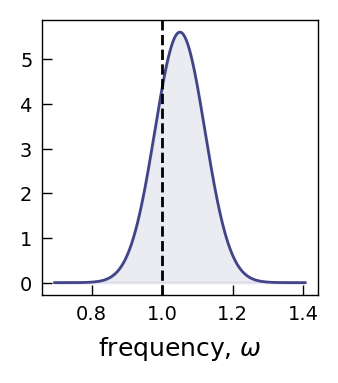

In [115]:
omega_err = np.sqrt(lambda_cov[0,0])
print(f'z-score: {(omega_map-omega)/omega_err:.5}')

x = np.linspace(omega_map-5*omega_err, omega_map+5*omega_err, 500)
pdf = stats.norm.pdf(x, loc=omega_map, scale=omega_err)

# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
plt.plot(x,pdf,color=cmap(0.2), label='true', lw=1)
plt.fill_between(x,pdf,alpha=0.1,color=cmap(0.2))

plt.axvline(x=omega, color='k', ls='--', lw=1, label='True value')

# Set axis labels with font size 9 pt
ax.set_xlabel(r'frequency, $\omega$', fontsize=9)

# Create legend (frame turned off)
# ax.legend(frameon=False, fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SP_Frequency.pdf')

z-score: 1.4504


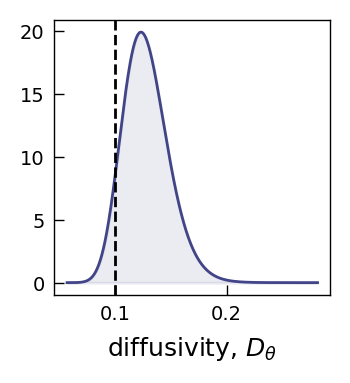

In [116]:
lnDtheta_err = np.sqrt(lambda_cov[1,1])
print(f'z-score: {(np.log(Dtheta_map)-np.log(Dtheta))/lnDtheta_err:.5}')

lnx = np.linspace(np.log(Dtheta_map)-5*lnDtheta_err, np.log(Dtheta_map)+5*lnDtheta_err, 500)
x = np.exp(lnx)
pdf = stats.lognorm.pdf(x, s=lnDtheta_err, scale=Dtheta_map)

# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
plt.plot(x,pdf,color=cmap(0.2), label='true', lw=1)
plt.fill_between(x,pdf,alpha=0.1,color=cmap(0.2))

plt.axvline(x=Dtheta, color='k', ls='--', lw=1, label='True value')

# Set axis labels with font size 9 pt
ax.set_xlabel(r'diffusivity, $D_\theta$', fontsize=9)
# ax.set_xscale('log')

# Create legend (frame turned off)
# ax.legend(frameon=False, fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SP_Diffusivity.pdf')

z-score: -0.37902


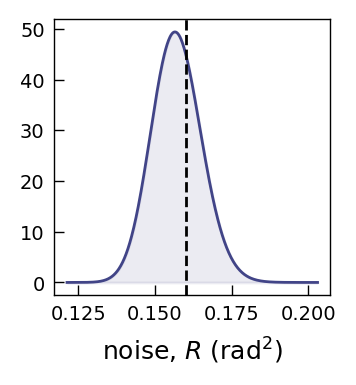

In [117]:
lnR_err = np.sqrt(lambda_cov[2,2])
print(f'z-score: {(np.log(R_map)-np.log(R))/lnR_err:.5}')

lnx = np.linspace(np.log(R_map)-5*lnR_err, np.log(R_map)+5*lnR_err, 500)
x = np.exp(lnx)
pdf = stats.lognorm.pdf(x, s=lnR_err, scale=R_map)

# Desired axes dimensions in centimeters
axes_width_cm = 3.5
axes_height_cm = 3.5

# Convert centimeters to inches (1 inch = 2.54 cm)
axes_width_in = axes_width_cm / 2.54    # ~2.362 in
axes_height_in = axes_height_cm / 2.54  # ~1.772 in

# Define margins for labels/ticks in inches (adjust as needed)
left_margin = 0.5
right_margin = 0.5
bottom_margin = 0.5
top_margin = 0.5

# Overall figure size in inches: axes area plus margins
fig_width = axes_width_in + left_margin + right_margin
fig_height = axes_height_in + bottom_margin + top_margin

# Create figure with computed size
fig = plt.figure(figsize=(fig_width, fig_height))

# Calculate normalized (0-1) coordinates for the axes
left_norm = left_margin / fig_width
bottom_norm = bottom_margin / fig_height
axes_width_norm = axes_width_in / fig_width
axes_height_norm = axes_height_in / fig_height

# Add axes with the computed position; this sets the axes frame to be exactly 6 cm by 4.5 cm.
ax = fig.add_axes([left_norm, bottom_norm, axes_width_norm, axes_height_norm])

# Plot the data
plt.plot(x,pdf,color=cmap(0.2), label='true', lw=1)
plt.fill_between(x,pdf,alpha=0.1,color=cmap(0.2))

plt.axvline(x=R, color='k', ls='--', lw=1, label='True value')

# Set axis labels with font size 9 pt
ax.set_xlabel(r'noise, $R$ (rad$^2$)', fontsize=9)

# Create legend (frame turned off)
# ax.legend(frameon=False, fontsize=8)

# Set tick label fonts to 7 pt, tick mark widths to 0.5 pt, and ticks pointing inward
ax.tick_params(axis='both', which='major', labelsize=7, width=0.5, direction='in')
ax.tick_params(axis='both', which='minor', labelsize=7, width=0.5, direction='in')

# Set the width of the frame (all spines) to 0.5 pt
for spine in ax.spines.values():
    spine.set_linewidth(0.5)

plt.savefig('SP_Noise.pdf')